# Common Task I: AutoEncoder Reconstruction
Reconstruction captures spatial energy patterns across ECAL, HCAL, and Tracks.

In [1]:
import os; os.chdir('/Users/sasisundar/Desktop/ml4sci-gsoc/ml4sci-gsoc')
import sys; sys.path.insert(0, '.')
import warnings; warnings.filterwarnings('ignore')


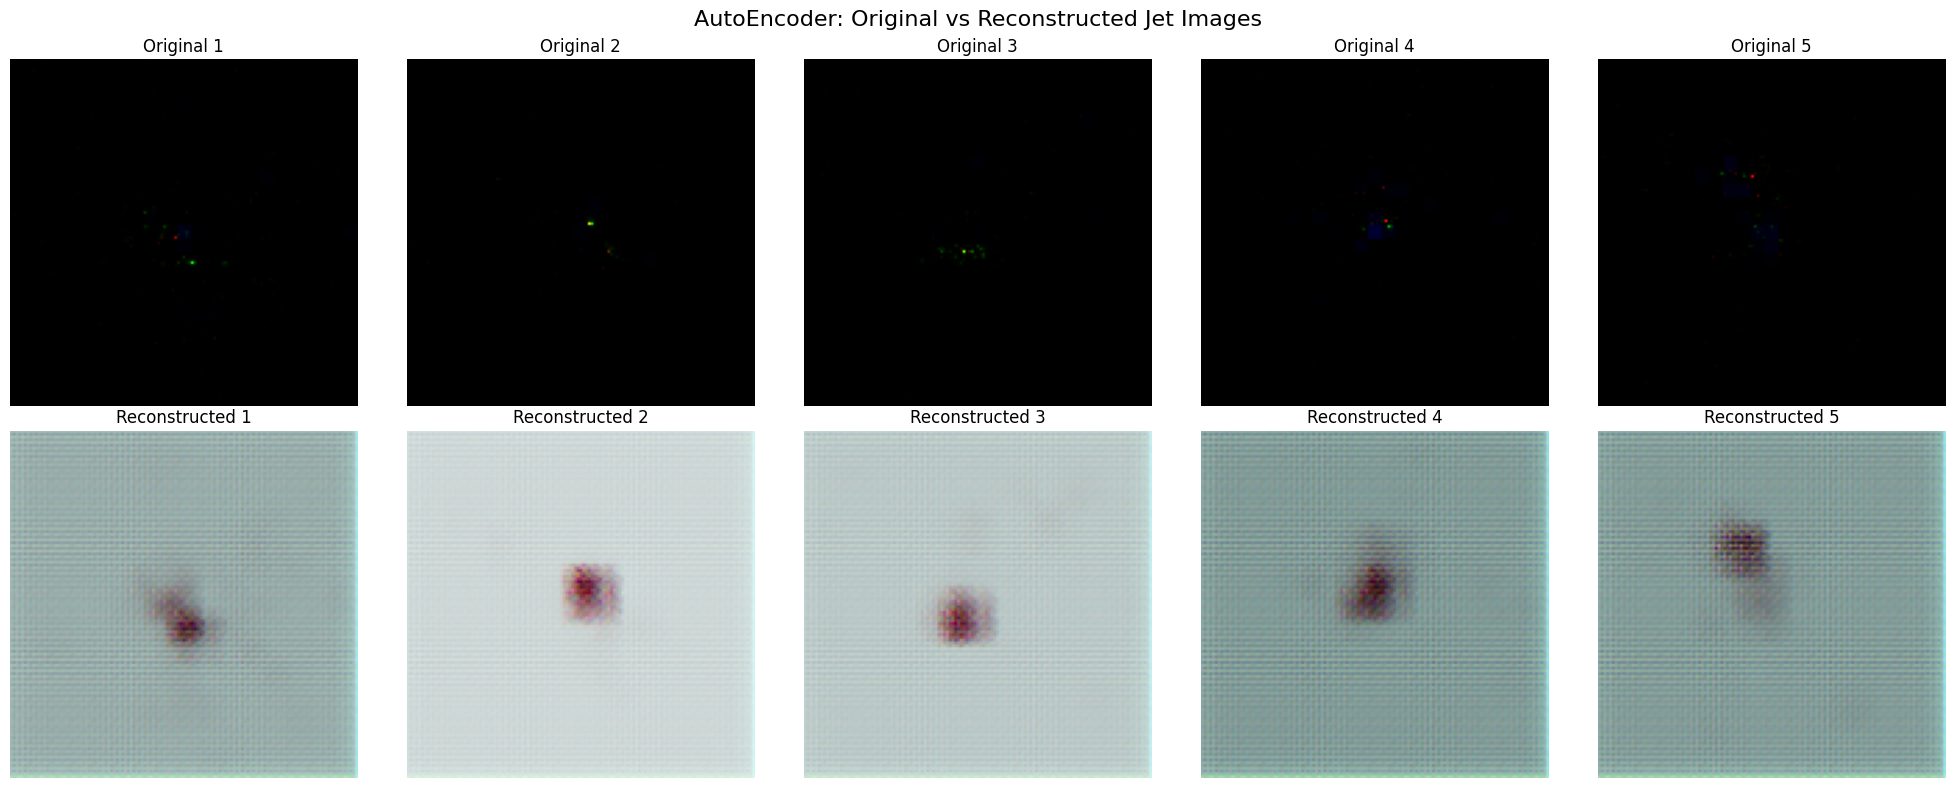

Reconstruction plot saved.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.models.autoencoder import AutoEncoder
from src.data.loader import JetDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = JetDataset('dataset.hdf5', max_samples=1000)

model = AutoEncoder().to(device)
model.load_state_dict(torch.load('outputs/models/autoencoder.pt', map_location=device, weights_only=True))
model.eval()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    img, _ = dataset[i]
    with torch.no_grad():
        recon = model(img.unsqueeze(0).to(device)).cpu()
    orig = img.permute(1, 2, 0).numpy()
    rec = recon.squeeze(0).permute(1, 2, 0).numpy()
    orig = (orig - orig.min()) / (orig.max() - orig.min() + 1e-8)
    rec = (rec - rec.min()) / (rec.max() - rec.min() + 1e-8)
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f'Original {i+1}')
    axes[0, i].axis('off')
    axes[1, i].imshow(rec)
    axes[1, i].set_title(f'Reconstructed {i+1}')
    axes[1, i].axis('off')

plt.suptitle('AutoEncoder: Original vs Reconstructed Jet Images', fontsize=16)
plt.tight_layout()
plt.savefig('outputs/plots/recon.png', dpi=150)
plt.show()
print('Reconstruction plot saved.')
